# Notebook 07 — SAE Analysis

Analyses trained Sparse Autoencoders at layers 7, 17, 21.

**Contents:**
1. Training loss curves — verify MSE decreases
2. Reconstruction quality (MSE, mean L0, dead feature %)
3. Top activating examples per feature
4. SAE feature × IR target correlation heatmap
5. Identifying prime intervention features for Phase 8

In [1]:
import os, sys, json
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
os.chdir(project_root)
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

from src.sae.sae_store import load_sae
from src.sae.evaluator import evaluate_sae
from src.sae.feature_analyzer import get_feature_activations, correlate_with_ir_features
from src.utils.io import load_parquet

SAE_LAYERS = [7, 17, 21]
DATASETS   = ["scifact", "nfcorpus"]

# Dataset-specific paths
CKPT_ROOT  = {d: Path(f"outputs/final/sae_checkpoints/{d}") for d in DATASETS}
ACTS_ROOT  = {d: Path(f"data/caches/activations/{d}") for d in DATASETS}   # decision-token
ANALYSIS   = {d: Path(f"outputs/final/sae_analysis/{d}") for d in DATASETS}

OUT_FIG = Path("outputs/midproject/figures")
OUT_FIG.mkdir(parents=True, exist_ok=True)

print("Working directory:", os.getcwd())

Working directory: /Users/vraj21/Desktop/Projects/LLM Reranker


## 1  Load checkpoints + metadata

In [2]:
saes, metas = {d: {} for d in DATASETS}, {d: {} for d in DATASETS}

for dataset in DATASETS:
    print(f"\n--- {dataset} ---")
    for l in SAE_LAYERS:
        sae, meta = load_sae(CKPT_ROOT[dataset] / f"layer{l}")
        saes[dataset][l] = sae
        metas[dataset][l] = meta
        print(f"  Layer {l:>2}  val_loss={meta['val_loss']:.4f}  "
              f"epoch={meta['epoch']}  k={meta['k']}")


--- scifact ---
  Layer  7  val_loss=0.1388  epoch=20  k=64
  Layer 17  val_loss=0.2813  epoch=20  k=64
  Layer 21  val_loss=0.6576  epoch=20  k=64

--- nfcorpus ---
  Layer  7  val_loss=0.1120  epoch=20  k=64
  Layer 17  val_loss=0.2498  epoch=20  k=64
  Layer 21  val_loss=0.5940  epoch=20  k=64


## 2  Reconstruction quality

In [3]:
all_rows = []
for dataset in DATASETS:
    for l in SAE_LAYERS:
        acts = np.load(ACTS_ROOT[dataset] / f"layer_{l}.npy", mmap_mode="r")
        metrics = evaluate_sae(saes[dataset][l], acts)
        all_rows.append({"dataset": dataset, "layer": l, **metrics})
        print(f"{dataset:<10} Layer {l:>2}  MSE={metrics['mse']:.4f}  "
              f"L0={metrics['mean_l0']:.1f}  dead={metrics['dead_feature_pct']:.1f}%")

eval_df = pd.DataFrame(all_rows)

print()
print("Go/No-Go (dead features <5%):")
for _, row in eval_df.iterrows():
    status = "✓" if row["dead_feature_pct"] < 5.0 else "✗"
    print(f"  {status} {row['dataset']} layer {int(row['layer'])}: {row['dead_feature_pct']:.1f}%")

scifact    Layer  7  MSE=0.0143  L0=64.0  dead=95.3%
scifact    Layer 17  MSE=0.0257  L0=64.0  dead=91.2%
scifact    Layer 21  MSE=0.0879  L0=64.0  dead=90.4%
nfcorpus   Layer  7  MSE=0.0311  L0=64.0  dead=96.9%
nfcorpus   Layer 17  MSE=0.0313  L0=64.0  dead=94.9%
nfcorpus   Layer 21  MSE=0.1681  L0=64.0  dead=93.2%

Go/No-Go (dead features <5%):
  ✗ scifact layer 7: 95.3%
  ✗ scifact layer 17: 91.2%
  ✗ scifact layer 21: 90.4%
  ✗ nfcorpus layer 7: 96.9%
  ✗ nfcorpus layer 17: 94.9%
  ✗ nfcorpus layer 21: 93.2%


## 3  Reconstruction MSE bar chart

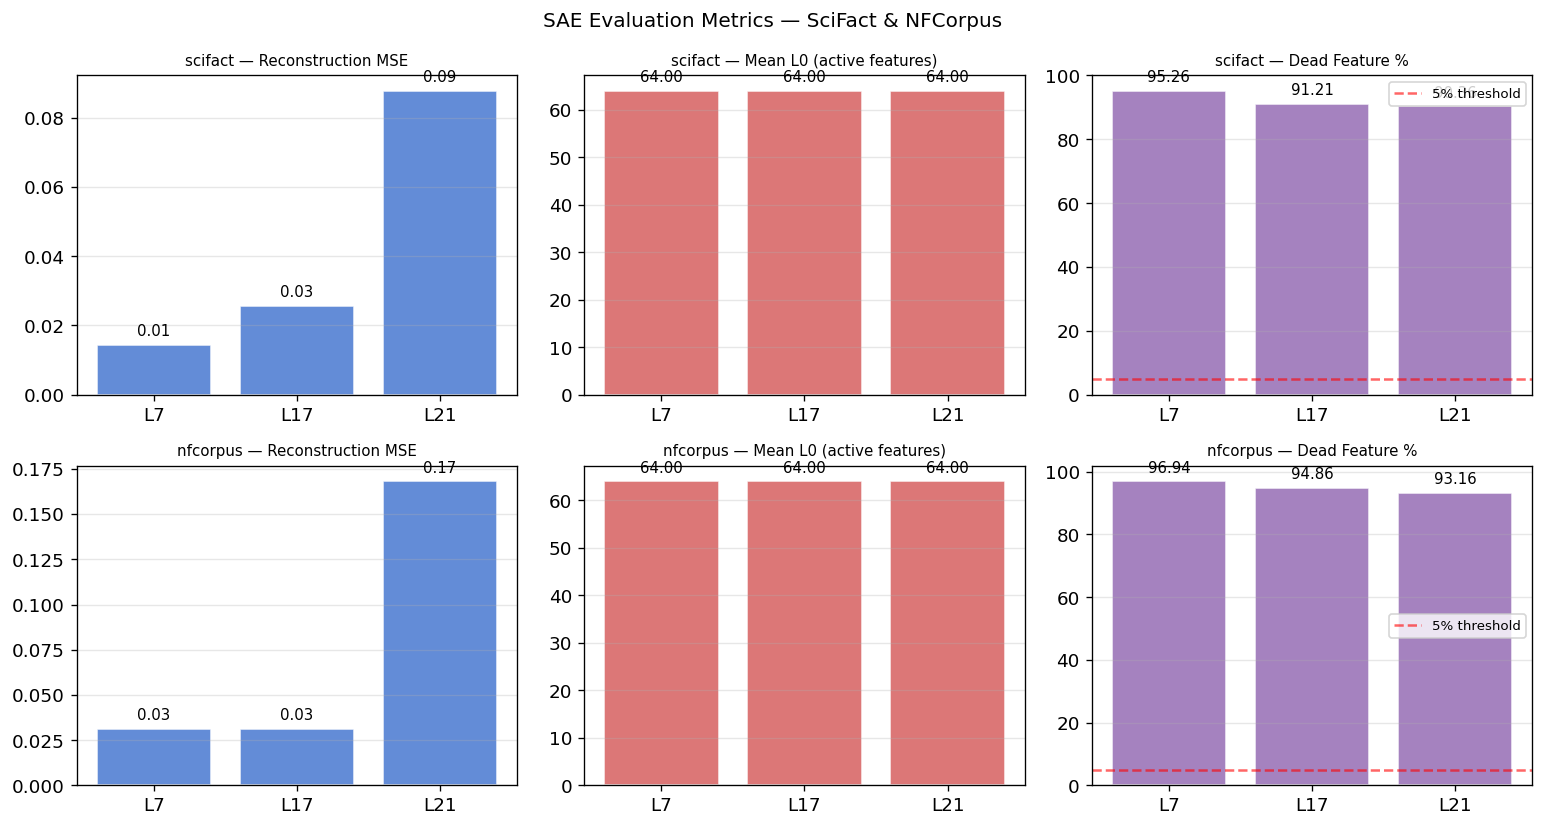

Saved.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
colors = ["#4878d0", "#d65f5f", "#956cb4"]
metrics_to_plot = [
    ("mse",              "Reconstruction MSE"),
    ("mean_l0",          "Mean L0 (active features)"),
    ("dead_feature_pct", "Dead Feature %"),
]

for row_idx, dataset in enumerate(DATASETS):
    sub = eval_df[eval_df["dataset"] == dataset]
    for col_idx, (col, label) in enumerate(metrics_to_plot):
        ax = axes[row_idx, col_idx]
        vals = [sub[sub["layer"] == l][col].values[0] for l in SAE_LAYERS]
        bars = ax.bar([f"L{l}" for l in SAE_LAYERS], vals,
                      color=colors[col_idx], alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(vals)*0.02,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=9)
        if col == "dead_feature_pct":
            ax.axhline(5.0, color="red", linestyle="--", alpha=0.6, label="5% threshold")
            ax.legend(fontsize=8)
        ax.set_title(f"{dataset} — {label}", fontsize=9)
        ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("SAE Evaluation Metrics — SciFact & NFCorpus", fontsize=12)
plt.tight_layout()
plt.savefig(OUT_FIG / "sae_eval_metrics.png", bbox_inches="tight")
plt.show()
print("Saved.")

## 4  SAE feature × IR target correlation heatmap

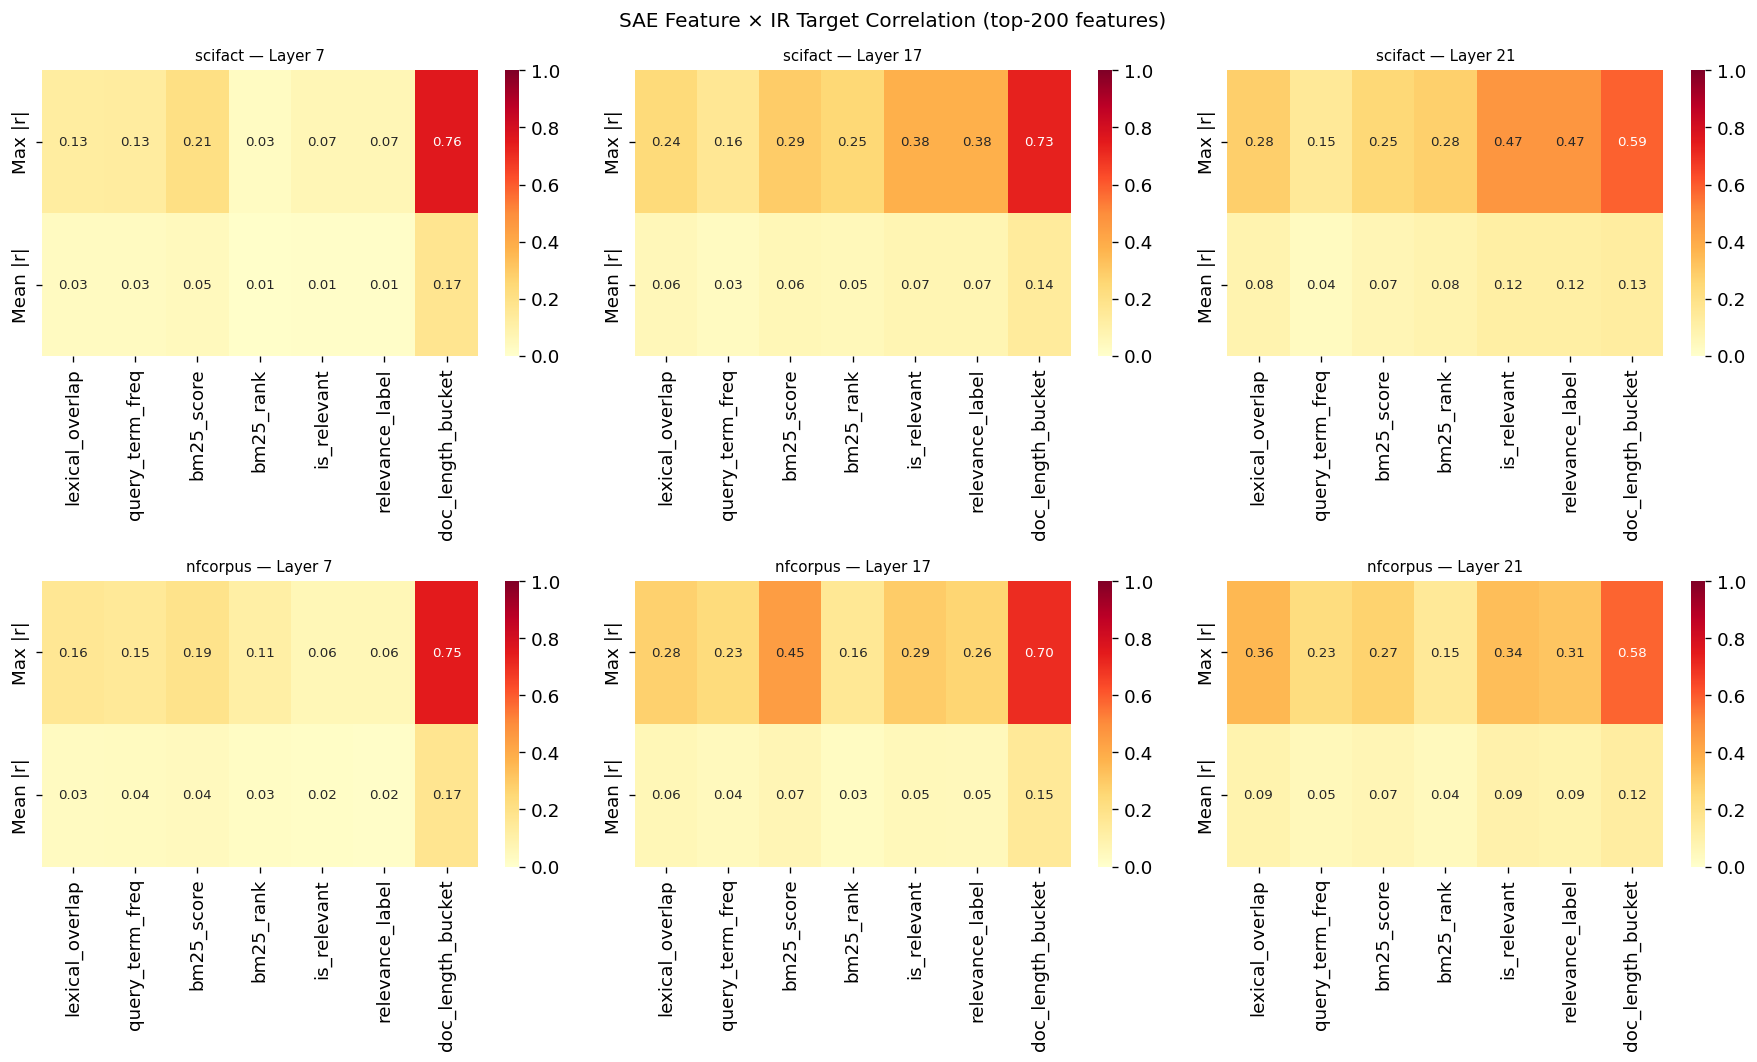

Saved.


In [5]:
import seaborn as sns

IR_TARGETS = ["lexical_overlap", "query_term_freq", "bm25_score",
              "bm25_rank", "is_relevant", "relevance_label", "doc_length_bucket"]

fig, axes = plt.subplots(2, len(SAE_LAYERS), figsize=(5 * len(SAE_LAYERS), 9))

for row_idx, dataset in enumerate(DATASETS):
    features_df = load_parquet(f"data/interim/{dataset}/features.parquet")
    for col_idx, l in enumerate(SAE_LAYERS):
        ax = axes[row_idx, col_idx]
        acts = np.load(ACTS_ROOT[dataset] / f"layer_{l}.npy", mmap_mode="r")
        sparse_codes = get_feature_activations(saes[dataset][l], acts)
        corr_df = correlate_with_ir_features(sparse_codes, features_df, top_k_features=200)

        r_cols   = [f"r_{t}" for t in IR_TARGETS if f"r_{t}" in corr_df.columns]
        max_r    = corr_df[r_cols].abs().max().rename(lambda c: c[2:])
        mean_r   = corr_df[r_cols].abs().mean().rename(lambda c: c[2:])
        heat_data = pd.DataFrame({"Max |r|": max_r, "Mean |r|": mean_r})

        sns.heatmap(heat_data.T, annot=True, fmt=".2f", cmap="YlOrRd",
                    vmin=0, vmax=1, ax=ax, annot_kws={"size": 8})
        ax.set_title(f"{dataset} — Layer {l}", fontsize=9)

plt.suptitle("SAE Feature × IR Target Correlation (top-200 features)", fontsize=12)
plt.tight_layout()
plt.savefig(OUT_FIG / "sae_ir_correlation.png", bbox_inches="tight")
plt.show()
print("Saved.")

## 5  Top activating examples for best is_relevant feature at layer 17

In [6]:
for dataset in DATASETS:
    examples_path = ANALYSIS[dataset] / "top_examples_layer17.json"
    corr_path     = ANALYSIS[dataset] / "ir_correlations_layer17.parquet"

    if not examples_path.exists():
        print(f"{dataset}: run scripts/phase7_sae.sh first.")
        continue

    features_df = load_parquet(f"data/interim/{dataset}/features.parquet")
    with open(examples_path) as f:
        top_examples = json.load(f)

    corr_df = pd.read_parquet(corr_path)
    best_feat_idx = str(corr_df["r_is_relevant"].abs().idxmax())
    best_r = corr_df.loc[int(best_feat_idx), "r_is_relevant"]

    print(f"\n{'─'*55}")
    print(f"{dataset} — Best is_relevant feature at layer 17")
    print(f"  feature_idx={best_feat_idx}  Pearson r={best_r:+.3f}")
    print(f"{'─'*55}")

    examples = top_examples.get(best_feat_idx, [])
    if examples:
        ex_df = pd.DataFrame(examples[:10])
        ex_df = ex_df.merge(
            features_df[["query_id", "doc_id", "is_relevant", "bm25_score"]],
            on=["query_id", "doc_id"], how="left"
        )
        print(ex_df.to_string(index=False))


───────────────────────────────────────────────────────
scifact — Best is_relevant feature at layer 17
  feature_idx=30  Pearson r=+0.382
───────────────────────────────────────────────────────
 rank query_id   doc_id  activation  is_relevant  bm25_score
    1      338 23349986    1.992791         True   34.725191
    2      723  5531479    1.911942         True   75.521040
    3      845 17741440    1.897530         True   44.436012
    4      124  4883040    1.851212         True   53.958563
    5      589 10984005    1.793465         True   91.525856
    6      248  1568684    1.778223         True   32.265856
    7      399   791050    1.757069         True   62.439563
    8     1150 11369420    1.718735         True   42.989811
    9     1012  9745001    1.713018         True   64.592074
   10      232 10536636    1.697740         True   57.846499

───────────────────────────────────────────────────────
nfcorpus — Best is_relevant feature at layer 17
  feature_idx=30  Pearson r=+

## 6  Prime intervention targets for Phase 8

In [7]:
for dataset in DATASETS:
    corr_path = ANALYSIS[dataset] / "ir_correlations_layer17.parquet"
    if not corr_path.exists():
        print(f"{dataset}: run scripts/phase7_sae.sh first.")
        continue

    corr_df = pd.read_parquet(corr_path)
    r_cols  = [c for c in corr_df.columns if c.startswith("r_")]

    print(f"\n{'─'*55}")
    print(f"{dataset} — Layer 17: Top SAE feature per IR target")
    print(f"{'IR Target':<22} {'Feature idx':>12} {'Pearson r':>10}")
    print("-" * 48)
    for col in r_cols:
        target   = col[2:]
        best_idx = corr_df[col].abs().idxmax()
        best_r   = corr_df.loc[best_idx, col]
        print(f"{target:<22} {best_idx:>12} {best_r:>+10.3f}")

print("\nThese feature indices are the Phase 8 SAE steering/ablation targets.")


───────────────────────────────────────────────────────
scifact — Layer 17: Top SAE feature per IR target
IR Target               Feature idx  Pearson r
------------------------------------------------
lexical_overlap                 746     -0.241
query_term_freq                1127     -0.164
bm25_score                     2166     -0.292
bm25_rank                       656     +0.251
is_relevant                      30     +0.382
relevance_label                  30     +0.382
doc_length_bucket              2345     +0.734

───────────────────────────────────────────────────────
nfcorpus — Layer 17: Top SAE feature per IR target
IR Target               Feature idx  Pearson r
------------------------------------------------
lexical_overlap                2252     -0.276
query_term_freq                 928     +0.231
bm25_score                     1048     +0.447
bm25_rank                      2803     +0.158
is_relevant                      30     +0.292
relevance_label              